In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

In [21]:
df = pd.read_csv('cardekho_data.csv')

In [22]:
df.head()

,Car_Name,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0


In [23]:
df.isnull().sum()

,0
Car_Name,0
Year,0
Selling_Price,0
Present_Price,0
Kms_Driven,0
Fuel_Type,0
Seller_Type,0
Transmission,0
Owner,0


In [24]:
# Mã hóa các cột dữ liệu dạng chữ
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()

encode_cols = ['Fuel_Type', 'Transmission', 'Seller_Type']
for col in encode_cols:
    df[col] = le.fit_transform(df[col])

In [25]:
df.columns

Index(['Car_Name', 'Year', 'Selling_Price', 'Present_Price', 'Kms_Driven',
       'Fuel_Type', 'Seller_Type', 'Transmission', 'Owner'],
      dtype='object')

In [26]:
df.head()

,Car_Name,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner
0,ritz,2014,3.35,5.59,27000,2,0,1,0
1,sx4,2013,4.75,9.54,43000,1,0,1,0
2,ciaz,2017,7.25,9.85,6900,2,0,1,0
3,wagon r,2011,2.85,4.15,5200,2,0,1,0
4,swift,2014,4.60,6.87,42450,1,0,1,0


In [27]:
Y = df['Selling_Price']
X = df.drop(['Car_Name', 'Selling_Price'], axis=1)
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42)
print(X_train.shape, X_test.shape)

(240, 7) (61, 7)


In [28]:
tree = DecisionTreeRegressor(max_depth=5, random_state=42)
tree.fit(X_train, Y_train)

DecisionTreeRegressor(max_depth=5, random_state=42)

In [30]:
Y_pred = tree.predict(X_test)
mse = mean_squared_error(Y_test, Y_pred)
mae = mean_absolute_error(Y_test, Y_pred)
r2 = r2_score(Y_test, Y_pred)
print(f'Mean Squared Error: {mse:.2f}')
print(f'Mean Absolute Error: {mae:.2f}')
print(f'R-squared: {r2:.2f}')

Mean Squared Error: 1.53
Mean Absolute Error: 0.81
R-squared: 0.93


In [32]:
print(Y_test[:5])
print(Y_pred[:5])

177     0.35
289    10.11
228     4.95
198     0.15
60      6.95
Name: Selling_Price, dtype: float64
[ 0.31424242 10.59882353  4.24444444  0.31424242  7.86      ]


In [34]:
depths = range(2, 21)
train_scores = []
test_scores = []

for d in depths:
    tree = DecisionTreeRegressor(max_depth=d, random_state=4)
    tree.fit(X_train, Y_train)
    train_scores.append(r2_score(Y_train, tree.predict(X_train)))
    test_scores.append(r2_score(Y_test, tree.predict(X_test)))

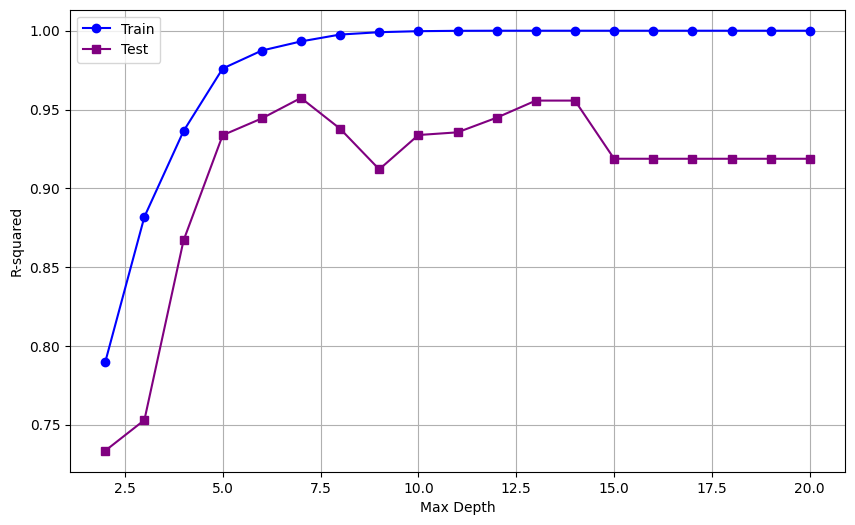

In [38]:
fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(depths, train_scores, 'o-', label='Train', color='blue')
ax.plot(depths, test_scores, 's-', label='Test', color='purple')
ax.set_xlabel('Max Depth')
ax.set_ylabel('R-squared')
ax.grid(True)
ax.legend()
plt.show()

In [40]:
best_depth = depths[np.argmax(test_scores)]
print(f'Best Max Depth: {best_depth}')

Best Max Depth: 7


In [42]:
print('Best r2:', np.max(test_scores))

Best r2: 0.9573385767472781


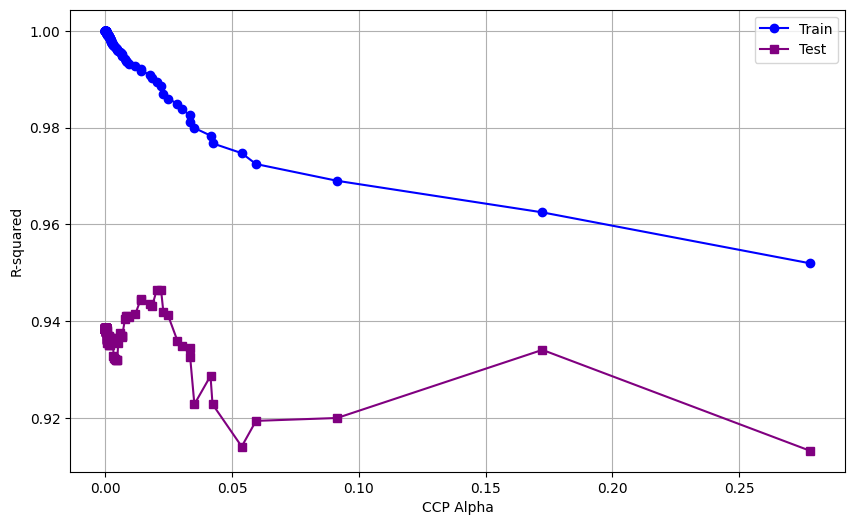

In [46]:
dt_full = DecisionTreeRegressor(random_state=42)
path = dt_full.cost_complexity_pruning_path(X_train, Y_train)
ccp_alphas = path.ccp_alphas[:-9]

train_scores = []
test_scores = []

for alpha in ccp_alphas:
    dt = DecisionTreeRegressor(random_state=42, ccp_alpha=alpha)
    dt.fit(X_train, Y_train)
    train_scores.append(r2_score(Y_train, dt.predict(X_train)))
    test_scores.append(r2_score(Y_test, dt.predict(X_test)))

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(ccp_alphas, train_scores, 'o-', label='Train', color='blue')
ax.plot(ccp_alphas, test_scores, 's-', label='Test', color='purple')
ax.set_xlabel('CCP Alpha')
ax.set_ylabel('R-squared')
ax.grid(True)
ax.legend()
plt.show()

In [47]:
print(f'Best alpha: {ccp_alphas[np.argmax(test_scores)]}')
print(f'Best r2: ', np.max(test_scores))

Best alpha: 0.020250000000000414
Best r2:  0.9464363092200452


In [49]:
rf = RandomForestRegressor(n_estimators=200, random_state=42, oob_score=True)
rf.fit(X_train, Y_train)

r2 = r2_score(Y_test, rf.predict(X_test))
print(f'R-squared: {r2:.2f}')

oomp = rf.oob_score_
print(f'Out-of-bag R-squared: {oomp:.2f}')

R-squared: 0.96
Out-of-bag R-squared: 0.88


Text(0.5, 1.0, 'Important features')

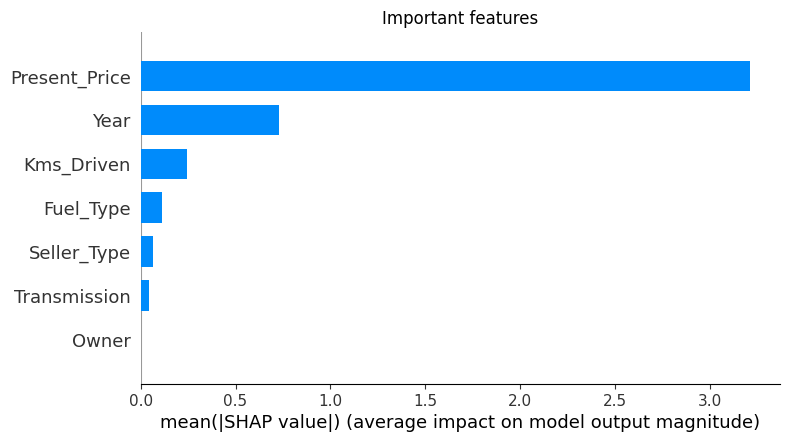

In [52]:
import shap
explainer = shap.TreeExplainer(rf)
shap_values = explainer.shap_values(X_test)

fig, ax = plt.subplots(figsize=(8, 4))
shap.summary_plot(shap_values, X_test, plot_type="bar", show=False)
plt.title('Important features')

Text(0.5, 1.0, 'Important features More detail')

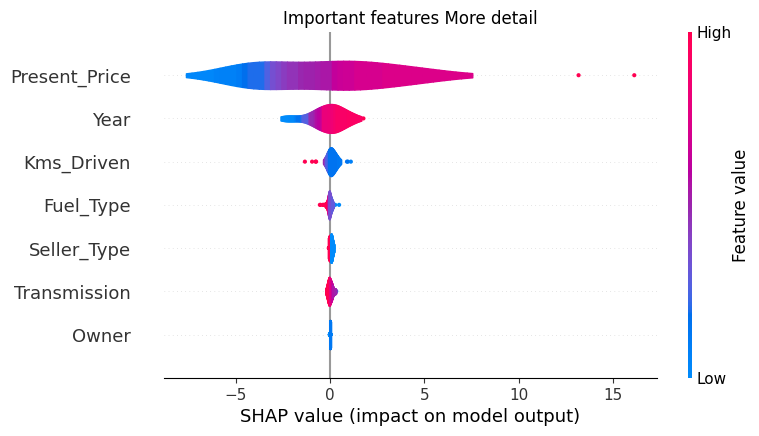

In [53]:
fig, ax = plt.subplots(figsize=(8, 4))
shap.summary_plot(shap_values, X_test, plot_type="violin", show=False)
plt.title('Important features More detail')

In [61]:
from sklearn.ensemble import IsolationForest

iso_f = IsolationForest(n_estimators=200,
                        contamination=0.01, # giả định tỉ lệ dữ liệu bất thường
                        random_state=42)

df_clean = df.copy()
df_clean['anomaly'] = iso_f.fit_predict(df_clean.drop(['Selling_Price', 'Car_Name'], axis=1))
df_clean['anomaly_score'] = iso_f.decision_function(df_clean.drop(['Selling_Price', 'Car_Name', 'anomaly'], axis=1))

n_anomalies = (df_clean['anomaly'] == -1).sum()
print(f'Phát hiện {n_anomalies} điểm bất thường / {len(df_clean)}')


Phát hiện 3 điểm bất thường / 301


In [62]:
df_clean.head()

,Car_Name,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner,anomaly,anomaly_score
0,ritz,2014,3.35,5.59,27000,2,0,1,0,1,0.304869
1,sx4,2013,4.75,9.54,43000,1,0,1,0,1,0.278090
2,ciaz,2017,7.25,9.85,6900,2,0,1,0,1,0.266220
3,wagon r,2011,2.85,4.15,5200,2,0,1,0,1,0.253574
4,swift,2014,4.60,6.87,42450,1,0,1,0,1,0.279786


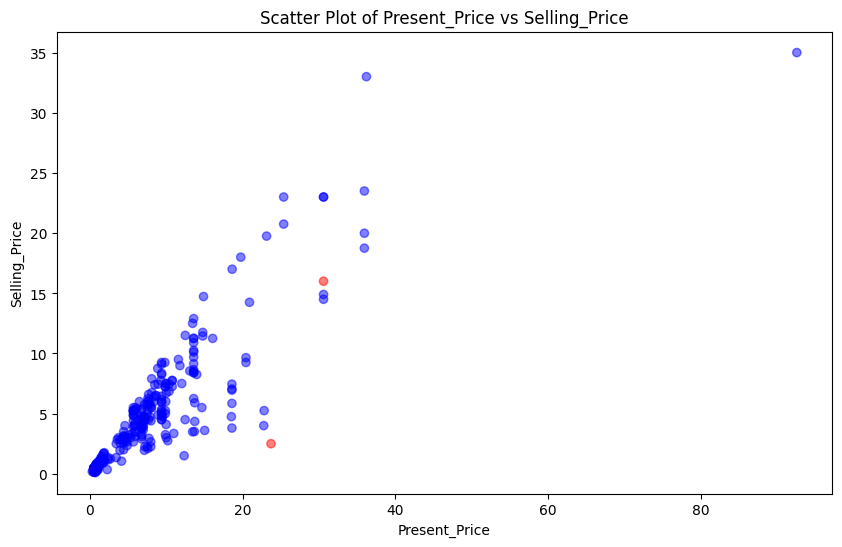

In [63]:
fig, ax = plt.subplots(figsize=(10, 6))
colors = df_clean['anomaly'].map({1: 'blue', -1: 'red'})
ax.scatter(df_clean['Present_Price'], df_clean['Selling_Price'], c=colors, alpha=0.5)
ax.set_xlabel('Present_Price')
ax.set_ylabel('Selling_Price')
ax.set_title('Scatter Plot of Present_Price vs Selling_Price')
plt.show()